# Toxic Comment Classification – Model Training

## Import Libraries

In [52]:
import sys
sys.path.append("../src")

from model_evaluation import evaluate_model

In [ ]:
import numpy as np                      # Numerical computing (arrays, matrix operations)
import pandas as pd                     # Data manipulation and analysis (DataFrames)
import pickle                           # Saving and loading trained models

import matplotlib.pyplot as plt         # Data visualization
import seaborn as sns                   # Statistical visualization

from sklearn.model_selection import GridSearchCV     # Hyperparameter tuning with cross-validation
from sklearn.preprocessing import StandardScaler     # Feature scaling for numerical features

from sklearn.metrics import (                         # Model evaluation metrics
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression   # Logistic Regression classifier
from sklearn.multiclass import OneVsRestClassifier    # Strategy for multi-label classification

from sklearn.naive_bayes import MultinomialNB         # Naive Bayes classifier (good for text data)
from sklearn.svm import LinearSVC                     # Linear Support Vector Machine classifier
from sklearn.neural_network import MLPClassifier      # Multi-layer Perceptron (neural network)
from sklearn.ensemble import RandomForestClassifier   # Random Forest ensemble classifier

from IPython.display import display                   # Better display of DataFrames in notebooks
from scipy import sparse                              # Handling sparse matrices (used for TF-IDF features)
import joblib

## Load Precomputed Features

### Load handcrafted features

In [55]:
X_train = pd.read_csv('../features/train_features.csv')
X_test = pd.read_csv('../features/test_features.csv')

In [56]:
labels = ['toxic','severe_toxic','obscene','threat','insult','identity_hate']

y_train = X_train[labels]
y_test = X_test[labels]

In [57]:
drop_cols = [
'comment_text',
'preprocessed_text',
'toxic','severe_toxic','obscene',
'threat','insult','identity_hate',
'any_label'
]

X_train_features = X_train.drop(columns=drop_cols)
X_test_features = X_test.drop(columns=drop_cols)

print(X_train_features.shape)

(127656, 20)


Handcrafted numerical features have different ranges, which can bias distance-based and gradient-based models. Therefore, we apply StandardScaler to normalize these features. TF-IDF and embedding features are not scaled because they are already normalized or structured representations of text.

In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

In [59]:
print("Train handcrafted feature shape:", X_train_scaled.shape)
print("Test handcrafted feature shape:", X_test_scaled.shape)

Train handcrafted feature shape: (127656, 20)
Test handcrafted feature shape: (31915, 20)


In [60]:
print('Y_train shape:', y_train.shape)
print('Y_test shape:', y_test.shape)

Y_train shape: (127656, 6)
Y_test shape: (31915, 6)


In [61]:
# Saving scaled handcrafted features for future use
joblib.dump(scaler, "../models/handcrafted_scaler.pkl")

np.save("../features/X_train_handcrafted_scaled.npy", X_train_scaled)
np.save("../features/X_test_handcrafted_scaled.npy", X_test_scaled)

### Load Tfidf Features

In [62]:
X_train_tfidf = sparse.load_npz("../features/X_train_tfidf.npz")
X_test_tfidf = sparse.load_npz("../features/X_test_tfidf.npz")

In [63]:
print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (127656, 5000)
Test TF-IDF shape: (31915, 5000)


### Load Word2vec Embeddings

In [64]:
X_train_word2vec = np.load('../features/X_train_w2v.npy')
X_test_word2vec  = np.load('../features/X_test_w2v.npy')

In [65]:
print('Train word2vec shape:', X_train_word2vec.shape)
print('Test word2vec shape:', X_test_word2vec.shape)

Train word2vec shape: (127656, 100)
Test word2vec shape: (31915, 100)


### Load Glove Embeddings

In [66]:
X_train_glove = np.load('../features/X_train_glove.npy')
X_test_glove  = np.load('../features/X_test_glove.npy')

In [67]:
print('Train glove shape:', X_train_glove.shape)
print('Test glove shape:', X_test_glove.shape)

Train glove shape: (127656, 100)
Test glove shape: (31915, 100)


## Baseline Model – Logistic Regression

## Logistic Regression

To establish an initial performance benchmark, we begin with Logistic Regression as our baseline model. Logistic Regression is widely used for text classification tasks because it performs well with high-dimensional sparse features such as TF-IDF vectors. Additionally, it is computationally efficient and easy to interpret. Since the toxic comment classification task is a multi-label problem, we employ the One-Vs-Rest strategy, which trains one binary classifier for each label.

### Logistic Regression on TFDIF

In [68]:
ovr_lr_tfidf = OneVsRestClassifier(LogisticRegression(max_iter=200, random_state=42))

In [69]:
print("Training Logistic Regression (TF-IDF)...")
ovr_lr_tfidf.fit(X_train_tfidf, y_train)

# Predictions
y_pred_lr_tfidf = ovr_lr_tfidf.predict(X_test_tfidf)
y_pred_proba_lr_tfidf = ovr_lr_tfidf.predict_proba(X_test_tfidf)

Training Logistic Regression (TF-IDF)...


In [70]:
print('Evaluation of Logistic Regression model on tfidf')
results_lr_tfidf, table_lr_tfidf = evaluate_model(y_test, y_pred_lr_tfidf, y_pred_proba_lr_tfidf, labels);

Evaluation of Logistic Regression model on tfidf

--- Global Metrics ---
precision_micro: 0.8554
recall_micro: 0.5723
f1_micro: 0.6858
precision_macro: 0.7652
recall_macro: 0.3986
f1_macro: 0.4992
roc_auc_macro: 0.9731
roc_auc_micro: 0.9790

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.889098,0.621142,0.731349,0.964169
1,severe_toxic,0.531469,0.249180,0.339286,0.983584
2,obscene,0.893008,0.637786,0.744121,0.978002
3,threat,0.785714,0.112245,0.196429,0.972526
4,insult,0.804566,0.559010,0.659678,0.974883
5,identity_hate,0.687500,0.212355,0.324484,0.965635


### Logistic regression on Handcrafted features

In [71]:
ovr_lr_hand = OneVsRestClassifier(LogisticRegression(max_iter=200, random_state=42))

print("Training Logistic Regression (handcrafted features)...")
ovr_lr_hand.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr_hand = ovr_lr_hand.predict(X_test_scaled)
y_pred_proba_lr_hand = ovr_lr_hand.predict_proba(X_test_scaled)

Training Logistic Regression (handcrafted features)...


In [72]:
print('Evaluation of Logistic Regression model on handcrafted features')
results_lr_hand, table_lr_hand = evaluate_model(y_test, y_pred_lr_hand, y_pred_proba_lr_hand, labels);

Evaluation of Logistic Regression model on handcrafted features

--- Global Metrics ---
precision_micro: 0.7895
recall_micro: 0.3149
f1_micro: 0.4502
precision_macro: 0.5909
recall_macro: 0.2062
f1_macro: 0.2962
roc_auc_macro: 0.8589
roc_auc_micro: 0.9040

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.837635,0.330269,0.473746,0.823442
1,severe_toxic,0.373737,0.121311,0.183168,0.907690
2,obscene,0.829439,0.427196,0.563940,0.870191
3,threat,0.454545,0.051020,0.091743,0.849764
4,insult,0.735915,0.265228,0.389925,0.858379
5,identity_hate,0.314286,0.042471,0.074830,0.844128


### Logistic Regression on word2vec

In [73]:
ovr_lr_w2v = OneVsRestClassifier(LogisticRegression(max_iter=200, random_state=42))

print("Training Logistic Regression (Word2Vec)...")
ovr_lr_w2v.fit(X_train_word2vec, y_train)

# Predictions
y_pred_lr_w2v = ovr_lr_w2v.predict(X_test_word2vec)
y_pred_proba_lr_w2v = ovr_lr_w2v.predict_proba(X_test_word2vec)

Training Logistic Regression (Word2Vec)...


In [74]:
print('Evaluation of Logistic Regression model on Word2vec features')
results_lr_w2v, table_lr_w2v = evaluate_model(y_test, y_pred_lr_w2v, y_pred_proba_lr_w2v, labels);

Evaluation of Logistic Regression model on Word2vec features

--- Global Metrics ---
precision_micro: 0.7329
recall_micro: 0.4234
f1_micro: 0.5367
precision_macro: 0.5951
recall_macro: 0.2760
f1_macro: 0.3593
roc_auc_macro: 0.9438
roc_auc_micro: 0.9590

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.768523,0.493762,0.601239,0.936287
1,severe_toxic,0.443662,0.206557,0.281879,0.969828
2,obscene,0.752239,0.454874,0.566929,0.945756
3,threat,0.636364,0.071429,0.128440,0.929050
4,insult,0.704358,0.379442,0.493196,0.949791
5,identity_hate,0.265306,0.050193,0.084416,0.932261


### Logistic Regression on Glove features

In [75]:
ovr_lr_glove = OneVsRestClassifier(LogisticRegression(max_iter=200, random_state=42))

print("Training Logistic Regression (Glove)...")
ovr_lr_glove.fit(X_train_glove, y_train)

# Predictions
y_pred_lr_glove = ovr_lr_glove.predict(X_test_glove)
y_pred_proba_lr_glove = ovr_lr_glove.predict_proba(X_test_glove)

Training Logistic Regression (Glove)...


In [76]:
print('Evaluation of Logistic Regression model on glove features')
results_lr_glove, table_lr_glove = evaluate_model(y_test, y_pred_lr_glove, y_pred_proba_lr_glove, labels);

Evaluation of Logistic Regression model on glove features

--- Global Metrics ---
precision_micro: 0.6598
recall_micro: 0.2803
f1_micro: 0.3935
precision_macro: 0.5010
recall_macro: 0.1731
f1_macro: 0.2481
roc_auc_macro: 0.9154
roc_auc_micro: 0.9359

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.697817,0.335850,0.453457,0.899275
1,severe_toxic,0.350000,0.068852,0.115068,0.942889
2,obscene,0.668005,0.300241,0.414280,0.909767
3,threat,0.250000,0.020408,0.037736,0.898960
4,insult,0.611465,0.243655,0.348457,0.916333
5,identity_hate,0.428571,0.069498,0.119601,0.925333


In [77]:
comparison_lr = pd.DataFrame({
    "TFIDF": results_lr_tfidf,
    "Handcrafted": results_lr_hand,
    "Word2Vec": results_lr_w2v,
    "GloVe": results_lr_glove
})

comparison_lr.T

,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,roc_auc_macro,roc_auc_micro
TFIDF,0.855391,0.572272,0.685759,0.765226,0.398620,0.499224,0.973133,0.979026
Handcrafted,0.789531,0.314857,0.450185,0.590926,0.206249,0.296225,0.858932,0.903960
Word2Vec,0.732868,0.423409,0.536728,0.595075,0.276043,0.359350,0.943829,0.958959
GloVe,0.659776,0.280305,0.393453,0.500976,0.173084,0.248100,0.915426,0.935934


The results indicate that TF-IDF features provide the best performance across all evaluation metrics, achieving the highest ROC-AUC, F1 score, and recall. This suggests that toxicity detection relies heavily on specific lexical patterns and offensive keywords, which TF-IDF captures effectively. Word embeddings such as Word2Vec and GloVe show moderate performance by capturing semantic relationships but slightly underperform compared to TF-IDF. Handcrafted features perform the worst, indicating that simple structural characteristics of comments are insufficient to accurately detect toxic language.

In [78]:
table_lr_tfidf

,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.889098,0.621142,0.731349,0.964169
1,severe_toxic,0.531469,0.249180,0.339286,0.983584
2,obscene,0.893008,0.637786,0.744121,0.978002
3,threat,0.785714,0.112245,0.196429,0.972526
4,insult,0.804566,0.559010,0.659678,0.974883
5,identity_hate,0.687500,0.212355,0.324484,0.965635


The label-wise evaluation shows that the model performs best on the more frequent categories such as toxic, obscene, and insult, achieving F1 scores above 0.65. In contrast, performance is significantly lower for minority classes such as threat, identity_hate, and severe_toxic, primarily due to their limited representation in the dataset.

## Additional Models

### Multinomial Naive Bayes (TF-IDF)

In [79]:
ovr_nb = OneVsRestClassifier(MultinomialNB())

In [80]:
print("Training Naive Bayes (TF-IDF)...")
ovr_nb.fit(X_train_tfidf, y_train)

# Predictions
y_pred_nb = ovr_nb.predict(X_test_tfidf)
y_pred_proba_nb = ovr_nb.predict_proba(X_test_tfidf)

Training Naive Bayes (TF-IDF)...


In [81]:
print('Evaluation of Naive Bayes model')
results_nb_tfidf, table_nb_tfidf = evaluate_model(y_test, y_pred_nb, y_pred_proba_nb, labels)

Evaluation of Naive Bayes model

--- Global Metrics ---
precision_micro: 0.8465
recall_micro: 0.4898
f1_micro: 0.6205
precision_macro: 0.5888
recall_macro: 0.3269
f1_macro: 0.4146
roc_auc_macro: 0.9570
roc_auc_micro: 0.9682

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.909039,0.524951,0.665557,0.952022
1,severe_toxic,0.514451,0.291803,0.372385,0.975599
2,obscene,0.873106,0.554753,0.678440,0.962932
3,threat,0.000000,0.000000,0.000000,0.939009
4,insult,0.793568,0.485406,0.602362,0.963335
5,identity_hate,0.442623,0.104247,0.168750,0.948952


### Linear Support Vector Machine (TF-IDF)

In [82]:
ovr_svm = OneVsRestClassifier(LinearSVC())

print("Training Linear SVM (TF-IDF)...")
ovr_svm.fit(X_train_tfidf, y_train)

# Predictions
y_pred_svm = ovr_svm.predict(X_test_tfidf)

# LinearSVC doesn't output probabilities
y_proba_svm = y_pred_svm

Training Linear SVM (TF-IDF)...


In [83]:
print("Evaluation of Linear SVM model")
results_svm_tfidf, table_svm_tfidf = evaluate_model(
    y_test,
    y_pred_svm,
    y_proba_svm,
    labels)

Evaluation of Linear SVM model

--- Global Metrics ---
precision_micro: 0.8330
recall_micro: 0.6183
f1_micro: 0.7098
precision_macro: 0.7206
recall_macro: 0.4448
f1_macro: 0.5356
roc_auc_macro: 0.7200
roc_auc_micro: 0.8068

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.862303,0.666120,0.751621,0.827448
1,severe_toxic,0.531915,0.245902,0.336323,0.621907
2,obscene,0.872067,0.693141,0.772377,0.843777
3,threat,0.629630,0.173469,0.272000,0.586578
4,insult,0.791806,0.600888,0.683261,0.796341
5,identity_hate,0.635593,0.289575,0.397878,0.644108


### Random Forest (TF-IDF)

In [84]:
ovr_rfc = OneVsRestClassifier(RandomForestClassifier(random_state = 42))

In [85]:
print("Training Random forest (TF-IDF)...")
ovr_rfc.fit(X_train_tfidf, y_train)

# Predictions
y_pred_rfc = ovr_rfc.predict(X_test_tfidf)
y_pred_proba_rfc = ovr_rfc.predict_proba(X_test_tfidf)

Training Random forest (TF-IDF)...


In [86]:
print("Evaluation of Random Forest model")
results_rf_tfidf, table_rf_tfidf = evaluate_model(
    y_test,
    y_pred_rfc,
    y_pred_proba_rfc,
    labels
)

Evaluation of Random Forest model

--- Global Metrics ---
precision_micro: 0.8204
recall_micro: 0.5926
f1_micro: 0.6881
precision_macro: 0.7062
recall_macro: 0.3769
f1_macro: 0.4507
roc_auc_macro: 0.9479
roc_auc_micro: 0.9673

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.847179,0.626067,0.720030,0.946999
1,severe_toxic,0.465753,0.111475,0.179894,0.970541
2,obscene,0.843552,0.720217,0.777020,0.969590
3,threat,0.666667,0.061224,0.112150,0.907650
4,insult,0.774917,0.592005,0.671223,0.961575
5,identity_hate,0.639344,0.150579,0.243750,0.931207


### MLP Classifier (TF-IDF)

In [87]:
ovr_mlp = OneVsRestClassifier(
    MLPClassifier(
        hidden_layer_sizes=(100,),
        max_iter=20,
        random_state=42
    )
)

In [88]:
print("Training MLP (TF-IDF)...")
ovr_mlp.fit(X_train_tfidf, y_train)

y_pred_mlp = ovr_mlp.predict(X_test_tfidf)
y_pred_proba_mlp = ovr_mlp.predict_proba(X_test_tfidf)

Training MLP (TF-IDF)...


/Users/nehayadav/Desktop/Ml-Projects/toxic-comment-classifier/toxic_env/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/nehayadav/Desktop/Ml-Projects/toxic-comment-classifier/toxic_env/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/nehayadav/Desktop/Ml-Projects/toxic-comment-classifier/toxic_env/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/nehayadav/Desktop/Ml-Projects/toxic-comment-classifier/toxic_env/lib/python3.11/site-packages/sklearn/neural_network/_multilay

In [89]:
print("Evaluation of MLP model")
results_mlp_tfidf, table_mlp_tfidf = evaluate_model(
    y_test,
    y_pred_mlp,
    y_pred_proba_mlp,
    labels
)

Evaluation of MLP model

--- Global Metrics ---
precision_micro: 0.7307
recall_micro: 0.6548
f1_micro: 0.6907
precision_macro: 0.5934
recall_macro: 0.5080
f1_macro: 0.5451
roc_auc_macro: 0.9534
roc_auc_micro: 0.9685

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.776782,0.683191,0.726987,0.947858
1,severe_toxic,0.390244,0.367213,0.378378,0.967265
2,obscene,0.782723,0.719615,0.749843,0.962316
3,threat,0.428571,0.275510,0.335404,0.941290
4,insult,0.703978,0.662437,0.682576,0.960084
5,identity_hate,0.478261,0.339768,0.397291,0.941685


## Model Comparison

In [90]:
model_comparison = pd.DataFrame({
    "Logistic Regression": results_lr_tfidf,
    "Naive Bayes": results_nb_tfidf,
    "Linear SVM": results_svm_tfidf,
    "Random Forest": results_rf_tfidf,
    "MLP": results_mlp_tfidf
}).T

model_comparison.round(3)

,precision_micro,recall_micro,f1_micro,precision_macro,recall_macro,f1_macro,roc_auc_macro,roc_auc_micro
Logistic Regression,0.855,0.572,0.686,0.765,0.399,0.499,0.973,0.979
Naive Bayes,0.846,0.490,0.621,0.589,0.327,0.415,0.957,0.968
Linear SVM,0.833,0.618,0.710,0.721,0.445,0.536,0.720,0.807
Random Forest,0.820,0.593,0.688,0.706,0.377,0.451,0.948,0.967
MLP,0.731,0.655,0.691,0.593,0.508,0.545,0.953,0.969


Among the evaluated models, Linear SVM achieved the highest F1-score and recall values, indicating superior performance in detecting toxic comments. Logistic Regression achieved the highest ROC-AUC score, demonstrating strong discrimination capability; however, Linear SVM produced better overall classification performance. Tree-based models such as Random Forest and probabilistic models like Naive Bayes performed reasonably well but did not outperform the linear models. Therefore, Linear SVM with TF-IDF features was selected as the final model for this task.

### Label wise performance for FINAL MODEL - LinearSVM (TF-IDF)

In [91]:
table_svm_tfidf

,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.862303,0.666120,0.751621,0.827448
1,severe_toxic,0.531915,0.245902,0.336323,0.621907
2,obscene,0.872067,0.693141,0.772377,0.843777
3,threat,0.629630,0.173469,0.272000,0.586578
4,insult,0.791806,0.600888,0.683261,0.796341
5,identity_hate,0.635593,0.289575,0.397878,0.644108


Logistic Regression achieved the highest ROC-AUC scores due to its probabilistic outputs, which allow better ranking of predictions. Linear SVM does not directly produce probability estimates, leading to lower ROC-AUC values. However, Linear SVM achieved higher F1 and recall scores, indicating better overall classification performance for detecting toxic comments.

## Hyperparameter Tuning – Linear SVM

In [92]:
svm_model = OneVsRestClassifier(LinearSVC(max_iter=5000))

param_grid = {
    "estimator__C": [0.01, 0.1, 1, 10],
    "estimator__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    svm_model,
    param_grid,
    scoring="f1_micro",
    cv=3,
    n_jobs=-1
)

print("Running GridSearchCV for Linear SVM...")
grid_search.fit(X_train_tfidf, y_train)

best_svm = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)

Running GridSearchCV for Linear SVM...
Best Parameters: {'estimator__C': 1, 'estimator__class_weight': None}


In [93]:
y_pred_svm_tuned = best_svm.predict(X_test_tfidf)

# still no probabilities
y_proba_svm_tuned = y_pred_svm_tuned

print("Evaluation of Tuned Linear SVM")
results_svm_tuned, table_svm_tuned = evaluate_model(
    y_test,
    y_pred_svm_tuned,
    y_proba_svm_tuned,
    labels
)

Evaluation of Tuned Linear SVM

--- Global Metrics ---
precision_micro: 0.8330
recall_micro: 0.6183
f1_micro: 0.7098
precision_macro: 0.7206
recall_macro: 0.4448
f1_macro: 0.5356
roc_auc_macro: 0.7200
roc_auc_micro: 0.8068

--- Per-label Metrics ---


,Label,Precision,Recall,F1,ROC-AUC
0,toxic,0.862303,0.666120,0.751621,0.827448
1,severe_toxic,0.531915,0.245902,0.336323,0.621907
2,obscene,0.872067,0.693141,0.772377,0.843777
3,threat,0.629630,0.173469,0.272000,0.586578
4,insult,0.791806,0.600888,0.683261,0.796341
5,identity_hate,0.635593,0.289575,0.397878,0.644108


Hyperparameter tuning was performed for the Linear SVM classifier using GridSearchCV. The regularization parameter C and the class_weight parameter were tuned to improve model performance and address the class imbalance present in the dataset.

### Compare F1 scores 

In [94]:
baseline_f1 = f1_score(y_test, y_pred_svm, average="micro")
tuned_f1 = f1_score(y_test, y_pred_svm_tuned, average="micro")

print("Baseline SVM F1:", baseline_f1)
print("Tuned SVM F1:", tuned_f1)

Baseline SVM F1: 0.709800033052388
Tuned SVM F1: 0.709800033052388


Hyperparameter tuning did not significantly improve performance, confirming that the default Linear SVM configuration was already optimal for this dataset.

### Save Final Model

In [102]:
with open("../models/final_svm_model.pkl", "wb") as f:
    pickle.dump(best_svm, f)

#save results to compare with other models in next notebook
with open("../features/svm_tuned_results.pkl", "wb") as f:
    pickle.dump(results_svm_tuned, f)

## Error Analysis

In [96]:
error_list = []

for i, label in enumerate(labels):

    temp = pd.DataFrame({
        "comment_text": X_test["comment_text"],
        "true": y_test[label],
        "pred": y_pred_svm_tuned[:, i]
    })

    temp["label"] = label

    # keep only mistakes
    temp = temp[temp["true"] != temp["pred"]]

    error_list.append(temp)

errors = pd.concat(error_list)

errors

,comment_text,true,pred,label
20,"""\nHe's also, to be fair, managed to use other...",1,0,toxic
21,Parasite Pig \n\nWith the recent death of the ...,0,1,toxic
25,"Oh so andy can have a history of this crap, ye...",1,0,toxic
36,Oppose Iset? Crazy.,1,0,toxic
70,(unless they relate to my hatred of Arabs),1,0,toxic
...,...,...,...,...
31475,MUST BE A ASS BUDDY OF CRUISERFAGGOT,1,0,identity_hate
31488,"Edit request from 174.3.185.61, 28 June 2010 \...",1,0,identity_hate
31555,I HOPE ISRAEL GETS WIPED OFF THE MAP,1,0,identity_hate
31602,Shut up! Are you Indian brother. i AM FROM tAM...,1,0,identity_hate


In [97]:
errors["label"].value_counts()

label
toxic            1341
insult            878
obscene           679
severe_toxic      296
identity_hate     227
threat             91
Name: count, dtype: int64

The majority of errors occur in the toxic and insult categories, while minority classes such as threat have fewer samples but relatively higher misclassification rates.

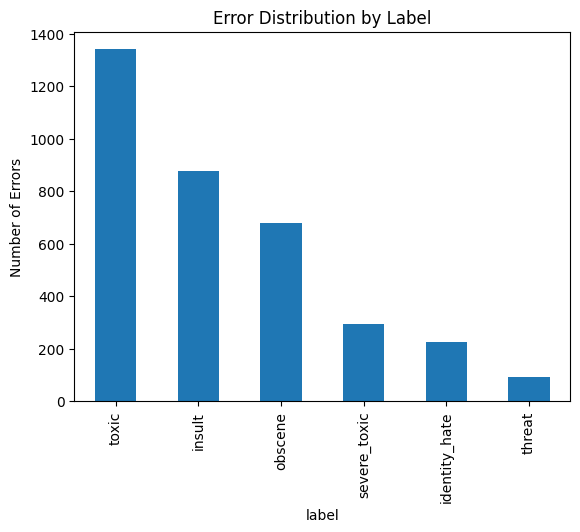

In [98]:
errors["label"].value_counts().plot(kind="bar")
plt.title("Error Distribution by Label")
plt.ylabel("Number of Errors")
plt.show()

### False Positives

In [99]:
for i, label in enumerate(labels):

    print(f"\n===== False Positives for {label} =====")

    fp = X_test[
        (y_test[label] == 0) &
        (y_pred_svm_tuned[:, i] == 1)
    ]

    display(fp["comment_text"].head(5))


===== False Positives for toxic =====


21     Parasite Pig \n\nWith the recent death of the ...
188    "\n\n Gregalton, You're Still A Douchebag, Sig...
204    .\n\nPerhaps it's neutral in MY point of you, ...
229    " \n jews \nthe only people that do conspiring...
521    "\nOf course it's censorship. You think censor...
Name: comment_text, dtype: str


===== False Positives for severe_toxic =====


1604    2008 (UTC)\n\nDont sweat these fucks, man, Vit...
1676    TIDEROLL LIKES TO GAG ON COCK \n\ntideroll is ...
2581    A little song \n\nFucky fucky fucky fuck\nFuck...
2621    Prepare \n\nyou are the biggest cock sucking m...
3414    Fuck you \n\nyeah you you fucking pseudo skept...
Name: comment_text, dtype: str


===== False Positives for obscene =====


...

2160     fuk u retard i hate u i will kill u bettr watc...
9490                               "destroy me"" but will"
12564    SHOOT YOURSELF YOU FREAK! SHOOT YOURSELF YOU F...
13271    If a girl ever sees you naked, she will cry fo...
20566     You do not deserve to be alive \n\nDrop dead now
Name: comment_text, dtype: str


===== False Positives for insult =====


120                                   shit my bitch hole
228    "\n\n Comunist ""Agents"" acting as wikipidia ...
260    Paul Tibbit is a fucking-ass little piece of s...
686    "\n\nUnwarranted warning\n\nYou gave me a warn...
971    Yes, you are a faggot!!!! BITCH ASS MOTHERFUCK...
Name: comment_text, dtype: str


===== False Positives for identity_hate =====


223                                Barek is probably gay.
1109    faggots faggots faggots faggots faggots faggot...
1117    Jiang = Shame! \n\nyou ain't down wit Freestyl...
1850                          Jew Aardvark, among others.
2125                          I see you are a faggot too.
Name: comment_text, dtype: str

The error analysis indicates that most false positives occur when the model encounters strong offensive keywords, which heavily influence TF-IDF features. Additionally, the multi-label nature of the dataset leads to label overlap between categories such as toxic, insult, and obscene. As a result, the classifier sometimes predicts a related label even when it is not present in the ground truth. These findings highlight the limitations of lexical-based models in capturing contextual nuances of toxic language.

### False Negatives

In [100]:
for i, label in enumerate(labels):

    print(f"\n===== False Negatives for {label} =====")

    fn = X_test[
        (y_test[label] == 1) &
        (y_pred_svm_tuned[:, i] == 0)
    ]

    display(fn["comment_text"].head(5))


===== False Negatives for toxic =====


20    "\nHe's also, to be fair, managed to use other...
25    Oh so andy can have a history of this crap, ye...
36                                  Oppose Iset? Crazy.
70           (unless they relate to my hatred of Arabs)
93    I don't care what you say here. I don't believ...
Name: comment_text, dtype: str


===== False Negatives for severe_toxic =====


2      Go to Hell, fatso \n\nHey, Dickwad! If you ign...
115                          NO! I DON'T CARE U BITCH!!!
132    LGagnon \ni for one, think lgagnon is a big fa...
260    Paul Tibbit is a fucking-ass little piece of s...
636                        Shut up, bitch. 38.116.200.66
Name: comment_text, dtype: str


===== False Negatives for obscene =====


...

346     Oh not you again!!! And so? After the block ha...
613     I will castrate you and roast your testicles. ...
866     Insult me once more and I swear you go down. U...
896                           go to  die \n\nson of  bich
1055    "\n\n A knife for you! \n\n  A knife for you! ...
Name: comment_text, dtype: str


===== False Negatives for insult =====


10                                Harvard Sucks.    Talk
15     "\n| ""ugly comments"" are a crime? Attacking ...
28                NAZIS RAUS \n\nSHUT THIS NAZI NIXER UP
97     Piss off fag! If you can't take the heat don't...
110    You are really a dog .... this is the photo of...
Name: comment_text, dtype: str


===== False Negatives for identity_hate =====


167    Hi afghani beggar refugee i love to suck the p...
193    PENIS VAGINA YOU SUCK FAGGOT ASSHOLES AT WIKIP...
196    Gays are disgusting\n\nIt's just my opinion bu...
229    " \n jews \nthe only people that do conspiring...
436    what they speak behind your back when they're ...
Name: comment_text, dtype: str

Overall, the error analysis shows that the model performs well for comments containing explicit offensive keywords but struggles with indirect toxicity, contextual threats, and rare classes such as threat and identity_hate. These challenges are common in traditional NLP approaches using TF-IDF features and highlight the potential benefit of contextual language models such as BERT.

### Confusion Matrix

To get count of FP and FN

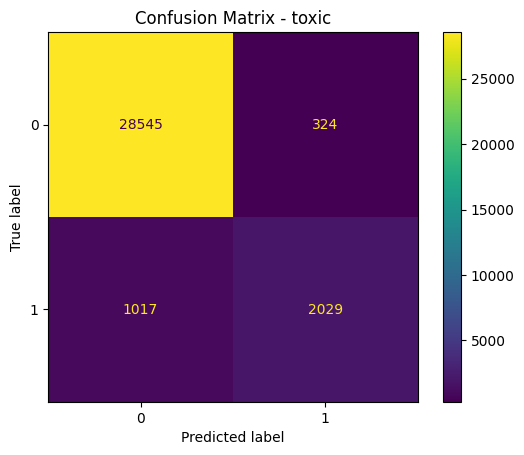

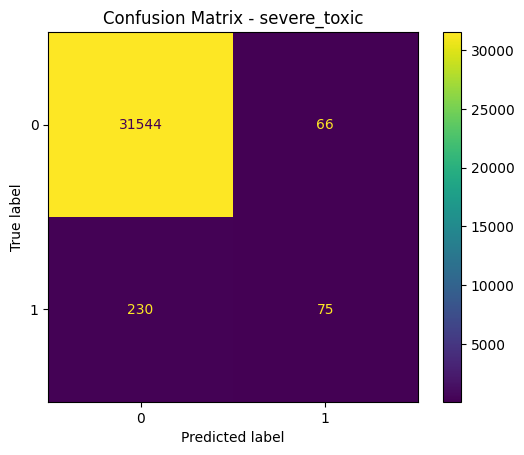

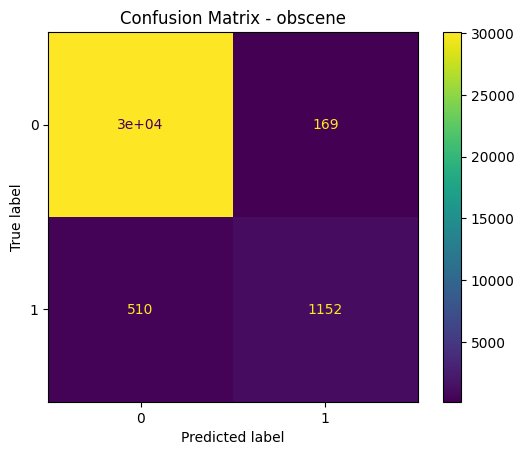

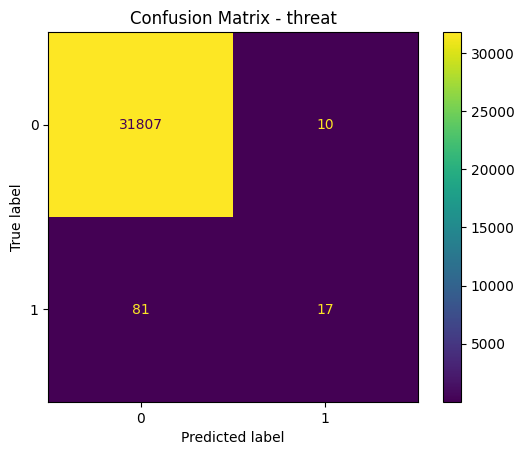

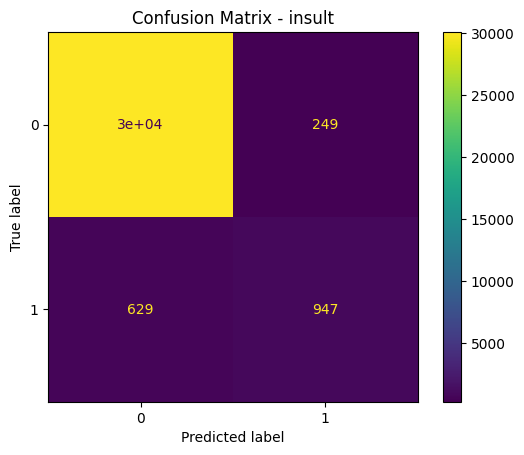

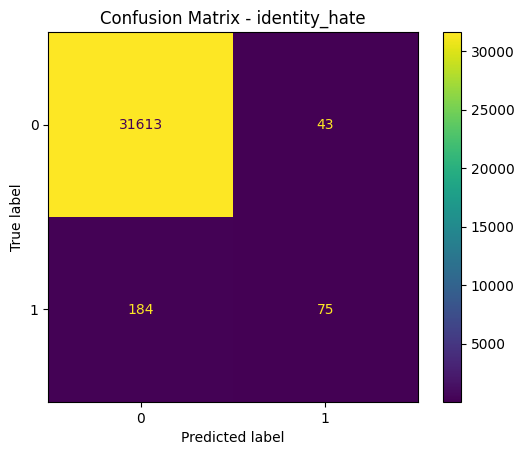

In [101]:
for i, label in enumerate(labels):

    cm = confusion_matrix(y_test[label], y_pred_svm_tuned[:, i])

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(f"Confusion Matrix - {label}")
    plt.show()

### Error Analysis Observations

The error analysis reveals that the classifier performs well for comments containing explicit offensive language but struggles with subtle or context-dependent toxicity. False positives often arise due to the presence of strong keywords that heavily influence TF-IDF features, while false negatives occur when toxicity is expressed indirectly. Additionally, overlapping labels in the multi-label dataset contribute to some misclassifications. Minority classes such as threat and identity_hate remain challenging due to class imbalance.

## Final Conclusion

In this study, multiple machine learning models were evaluated for toxic comment classification using different feature representations. Linear SVM with TF-IDF features achieved the best overall performance in terms of F1-score and recall. Hyperparameter tuning confirmed that the default Linear SVM configuration was already optimal for this dataset. Error analysis revealed that the model performs well for explicit toxic language but struggles with subtle toxicity and minority classes such as threat and identity_hate. Future improvements could involve contextual language models such as BERT to better capture semantic context.

## Future Work

Future improvements could include experimenting with contextual embeddings such as BERT or RoBERTa, applying advanced techniques for handling class imbalance, and exploring deep learning architectures for improved toxic comment detection.